In [1]:
"""
Adjacent power analyses WITHOUT new datasets, using a "data+design program" language.

Pipeline:
A) Load one mortality dataset (state×year deaths/pop).
B) Compute baseline simulated power curve (TWFE DiD toy design).
C) LLM proposes multiple DATA+DESIGN programs:
   - Data ops: row filter, outcome transform (y), optional aggregation
   - Design ops: pseudo adoption year, pre/post window, n_treated, effect grid, n_sim
D) Execute each program; run power simulation; compute MDE; plot:
   - Multi-alpha power curves per program
   - Comparison plot at alpha=0.05 across programs

Install:
pip install numpy pandas matplotlib scipy python-dotenv openai pydantic
"""

from __future__ import annotations

import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field


# =============================================================================
# SETTINGS
# =============================================================================

BASELINE_PATH = Path("Multiple Cause of Death, 1999-2020.csv")

ALPHAS = [0.10, 0.05, 0.01, 0.001]
TARGET_POWER = 80.0
ALPHA_FOR_MDE = 0.05
RNG_SEED = 1234

# Baseline design (same as before)
BASELINE_PROGRAM = dict(
    program_id="baseline",
    rationale="Baseline: log mortality rate per 100k + 1, state×year, pseudo post=2011",
    data_ops=dict(
        filter_query=None,
        outcome_transform="log_rate",  # log(100k*deaths/pop + 1)
        aggregate=None,                # keep as state×year
    ),
    design_ops=dict(
        last_year=2011,
        pre_years=5,
        post_years=3,
        n_treated=23,
        n_sim=500,
        effect_grid_step=0.0025,
        effect_grid_end=0.05,
    )
)


# =============================================================================
# A) LOAD ONE WONDER DATASET
# =============================================================================

def load_wonder_state_year(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df = df[df["year"].notna()].copy()
    df["year"] = df["year"].astype(int)

    df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
    df["population"] = pd.to_numeric(df["population"], errors="coerce")
    df = df.dropna(subset=["deaths", "population"])

    # state id
    if "state_code" in df.columns:
        df["state_id"] = pd.to_numeric(df["state_code"], errors="coerce").astype(int)
    elif "statecode" in df.columns:
        df["state_id"] = pd.to_numeric(df["statecode"], errors="coerce").astype(int)
    else:
        raise ValueError("Missing state_code/statecode column")

    df = df.sort_values(["state_id", "year"]).reset_index(drop=True)
    return df


# =============================================================================
# B) POWER SIM CORE (parameterized by a program)
# =============================================================================

def make_effect_grid(step: float, endv: float) -> np.ndarray:
    return np.arange(0.0, endv + 1e-12, step)

def add_outcome_column(df: pd.DataFrame, transform: str) -> pd.DataFrame:
    """
    Create y from deaths/pop. Keep this restricted and safe (no arbitrary eval).
    """
    df = df.copy()
    rate = 100000.0 * (df["deaths"] / df["population"])
    if transform == "log_rate":
        df["y"] = np.log(rate + 1.0)
    elif transform == "level_rate":
        df["y"] = rate
    elif transform == "asinh_rate":
        df["y"] = np.arcsinh(rate)
    else:
        raise ValueError(f"Unknown outcome_transform: {transform}")
    return df

def apply_data_ops(df_all: pd.DataFrame, data_ops: dict) -> pd.DataFrame:
    """
    data_ops:
      - filter_query: pandas query string (optional)
      - outcome_transform: one of {log_rate, level_rate, asinh_rate}
      - aggregate: optional dict specifying aggregation
    """
    df = df_all.copy()

    # 1) optional filter
    fq = data_ops.get("filter_query")
    if fq:
        # only allow queries that reference existing columns
        # (pandas will error otherwise)
        df = df.query(fq).copy()

    # 2) optional aggregation (for now, allow only regrouping to state×year sums)
    agg = data_ops.get("aggregate")
    if agg:
        # Simple safe aggregation schema:
        # {"groupby": ["state_id","year"], "sum": ["deaths","population"]}
        groupby_cols = agg.get("groupby", ["state_id", "year"])
        sum_cols = agg.get("sum", ["deaths", "population"])
        df = df.groupby(groupby_cols, as_index=False)[sum_cols].sum()

    # 3) outcome transform to create y
    df = add_outcome_column(df, data_ops.get("outcome_transform", "log_rate"))

    # enforce sort
    df = df.sort_values(["state_id", "year"]).reset_index(drop=True)
    return df

def simulate_power(df: pd.DataFrame, design_ops: dict, seed: int) -> pd.DataFrame:
    """
    df must contain: state_id, year, deaths, population, y
    """
    rng = np.random.default_rng(seed)

    last_year = int(design_ops["last_year"])
    pre_years = int(design_ops["pre_years"])
    post_years = int(design_ops["post_years"])
    n_treated = int(design_ops["n_treated"])
    n_sim = int(design_ops["n_sim"])
    step = float(design_ops["effect_grid_step"])
    endv = float(design_ops["effect_grid_end"])

    win_start = last_year - pre_years
    win_end = last_year + post_years

    dfx = df[(df["year"] >= win_start) & (df["year"] < win_end)].copy()
    if dfx.empty:
        raise ValueError(f"Empty window: {win_start}-{win_end-1}")

    effect_grid = make_effect_grid(step, endv)

    # index encoding
    state_codes = np.sort(dfx["state_id"].unique())
    year_vals = np.sort(dfx["year"].unique())
    state_to_idx = {s:i for i,s in enumerate(state_codes)}
    year_to_idx  = {y:i for i,y in enumerate(year_vals)}

    s = dfx["state_id"].map(state_to_idx).to_numpy()
    tt = dfx["year"].map(year_to_idx).to_numpy()
    S, T = len(state_codes), len(year_vals)

    deaths0 = dfx["deaths"].to_numpy().astype(int)
    pop = dfx["population"].to_numpy().astype(float)
    w = pop
    post = (dfx["year"].to_numpy() >= last_year).astype(int)

    def twoway_demean(x: np.ndarray) -> np.ndarray:
        x_bar = (w * x).sum() / w.sum()
        xs = np.bincount(s, weights=w * x, minlength=S) / np.bincount(s, weights=w, minlength=S)
        xt = np.bincount(tt, weights=w * x, minlength=T) / np.bincount(tt, weights=w, minlength=T)
        return x - xs[s] - xt[tt] + x_bar

    def twfe_beta_se(y: np.ndarray, d: np.ndarray):
        yt = twoway_demean(y)
        dt = twoway_demean(d)

        bread = np.sum(w * dt * dt)
        beta = np.sum(w * dt * yt) / bread

        u = yt - beta * dt
        score_g = np.bincount(s, weights=(w * dt * u), minlength=S)
        var_beta = np.sum(score_g**2) / (bread**2)

        return beta, np.sqrt(var_beta), (S - 1)

    J = len(effect_grid)
    pvals = np.empty((n_sim, J))
    state_idx = np.arange(S)

    y_base = dfx["y"].to_numpy()  # used only for shape; we regenerate via deaths thinning below

    for k in range(n_sim):
        treated_states = rng.choice(state_idx, size=min(n_treated, S), replace=False)
        treated = np.isin(s, treated_states).astype(int)
        d = treated * post

        for j, eff in enumerate(effect_grid):
            removed = rng.binomial(n=deaths0, p=eff) * d
            deaths_eff = deaths0 - removed

            # recompute y using same transform as in df['y'] definition
            # We reconstruct y from deaths_eff/pop using the SAME transform logic:
            rate = 100000.0 * (deaths_eff / pop)
            # detect which transform was used by checking monotone property of y_base? too hard;
            # instead store transform externally; we will do that in the program runner.
            # Here we assume df['y'] is log_rate, level_rate, or asinh_rate computed earlier.
            # We'll infer transform by comparing y_base type is float; not enough.
            # So: we will pass transform in via closure in the runner below.
            raise RuntimeError("simulate_power should be called through run_program(), which provides transform-specific recompute.")

    # unreachable
    return pd.DataFrame()

In [2]:
def simulate_power_with_transform(dfx: pd.DataFrame, design_ops: dict, outcome_transform: str, seed: int) -> pd.DataFrame:
    """
    Same as simulate_power but recomputes y consistently from deaths_eff/pop using outcome_transform.
    """
    rng = np.random.default_rng(seed)

    last_year = int(design_ops["last_year"])
    pre_years = int(design_ops["pre_years"])
    post_years = int(design_ops["post_years"])
    n_treated = int(design_ops["n_treated"])
    n_sim = int(design_ops["n_sim"])
    step = float(design_ops["effect_grid_step"])
    endv = float(design_ops["effect_grid_end"])

    win_start = last_year - pre_years
    win_end = last_year + post_years

    df = dfx[(dfx["year"] >= win_start) & (dfx["year"] < win_end)].copy()
    if df.empty:
        raise ValueError(f"Empty window: {win_start}-{win_end-1}")

    effect_grid = make_effect_grid(step, endv)

    state_codes = np.sort(df["state_id"].unique())
    year_vals = np.sort(df["year"].unique())
    state_to_idx = {s:i for i,s in enumerate(state_codes)}
    year_to_idx  = {y:i for i,y in enumerate(year_vals)}

    s = df["state_id"].map(state_to_idx).to_numpy()
    tt = df["year"].map(year_to_idx).to_numpy()
    S, T = len(state_codes), len(year_vals)

    deaths0 = df["deaths"].to_numpy().astype(int)
    pop = df["population"].to_numpy().astype(float)
    w = pop
    post = (df["year"].to_numpy() >= last_year).astype(int)

    def twoway_demean(x: np.ndarray) -> np.ndarray:
        x_bar = (w * x).sum() / w.sum()
        xs = np.bincount(s, weights=w * x, minlength=S) / np.bincount(s, weights=w, minlength=S)
        xt = np.bincount(tt, weights=w * x, minlength=T) / np.bincount(tt, weights=w, minlength=T)
        return x - xs[s] - xt[tt] + x_bar

    def twfe_beta_se(y: np.ndarray, d: np.ndarray):
        yt = twoway_demean(y)
        dt = twoway_demean(d)

        bread = np.sum(w * dt * dt)
        beta = np.sum(w * dt * yt) / bread

        u = yt - beta * dt
        score_g = np.bincount(s, weights=(w * dt * u), minlength=S)
        var_beta = np.sum(score_g**2) / (bread**2)

        return beta, np.sqrt(var_beta), (S - 1)

    J = len(effect_grid)
    pvals = np.empty((n_sim, J))
    state_idx = np.arange(S)

    for k in range(n_sim):
        treated_states = rng.choice(state_idx, size=min(n_treated, S), replace=False)
        treated = np.isin(s, treated_states).astype(int)
        d = treated * post

        for j, eff in enumerate(effect_grid):
            removed = rng.binomial(n=deaths0, p=eff) * d
            deaths_eff = deaths0 - removed

            rate = 100000.0 * (deaths_eff / pop)
            if outcome_transform == "log_rate":
                y = np.log(rate + 1.0)
            elif outcome_transform == "level_rate":
                y = rate
            elif outcome_transform == "asinh_rate":
                y = np.arcsinh(rate)
            else:
                raise ValueError(f"Unknown outcome_transform: {outcome_transform}")

            beta, se_beta, df_t = twfe_beta_se(y, d)

            # t-stat built on percent transform (matches your earlier approach)
            b_pct = 100.0 * (np.exp(beta) - 1.0) if outcome_transform == "log_rate" else 100.0 * beta
            se_pct = 100.0 * np.exp(beta) * se_beta if outcome_transform == "log_rate" else 100.0 * se_beta
            tstat = b_pct / se_pct
            pvals[k, j] = 2 * t.sf(np.abs(tstat), df=df_t)

    out = pd.DataFrame({"effect_size_pct": effect_grid * 100})
    for a in ALPHAS:
        out[f"power_{a:.3f}"] = (pvals <= a).mean(axis=0) * 100

    return out

def mde_from_power_curve(power_df: pd.DataFrame, alpha=ALPHA_FOR_MDE, target_power=TARGET_POWER) -> float:
    col = f"power_{alpha:.3f}"
    gap = np.abs(power_df[col] - target_power)
    i1, i2 = np.argsort(gap.values)[:2]
    x1, x2 = power_df.loc[[i1, i2], "effect_size_pct"].values
    y1, y2 = power_df.loc[[i1, i2], col].values
    m = (y2 - y1) / (x2 - x1)
    b0 = y1 - m * x1
    return float((target_power - b0) / m)

In [3]:
class DataOps(BaseModel):
    filter_query: str | None = None
    outcome_transform: str = Field(..., description="One of: log_rate, level_rate, asinh_rate")
    aggregate: dict | None = None

class DesignOps(BaseModel):
    last_year: int
    pre_years: int
    post_years: int
    n_treated: int
    n_sim: int
    effect_grid_step: float
    effect_grid_end: float

class Program(BaseModel):
    program_id: str
    rationale: str
    data_ops: DataOps
    design_ops: DesignOps

class ProgramMenu(BaseModel):
    programs: list[Program]

def propose_programs_via_llm(df_all: pd.DataFrame, baseline_program: dict, k: int = 4) -> ProgramMenu:
    load_dotenv()
    client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

    schema = {
        "columns": df_all.columns.tolist(),
        "dtypes": df_all.dtypes.astype(str).to_dict(),
        "year_min": int(df_all["year"].min()),
        "year_max": int(df_all["year"].max()),
        "n_states": int(df_all["state_id"].nunique()),
    }

    prompt = f"""
You are proposing {k} adjacent *data+design programs* for a simulated power analysis using ONE pandas DataFrame.

Data schema:
{json.dumps(schema, indent=2)}

Baseline program:
{json.dumps(baseline_program, indent=2)}

You may propose variants by changing:
DATA OPS (pandas-like):
- filter_query: a pandas query string using ONLY available columns
- outcome_transform: one of ["log_rate","level_rate","asinh_rate"]
- aggregate: either null or {{"groupby":["state_id","year"],"sum":["deaths","population"]}} (safe aggregation)

DESIGN OPS (simulation):
- last_year in [2008, 2012]
- pre_years in [3, 12]
- post_years in [1, 10]
- n_treated in [5, 45]
- n_sim in [50, 800]
- effect_grid_step in [0.001, 0.01]
- effect_grid_end in [0.02, 0.10]

Return ONLY valid JSON matching:
{{"programs":[{{"program_id":"...","rationale":"...","data_ops":{{...}},"design_ops":{{...}}}}, ...]}}
No markdown.

Goal: propose programs that change detectability (MDE/power) in interpretable ways.
"""
    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role":"system","content":"Return only valid JSON. No markdown."},
            {"role":"user","content":prompt},
        ],
        temperature=0.3,
    )
    raw = resp.choices[0].message.content
    return ProgramMenu.model_validate_json(raw)


=== Baseline program ===
Baseline MDE (α=0.05, 80.0% power): 3.183%


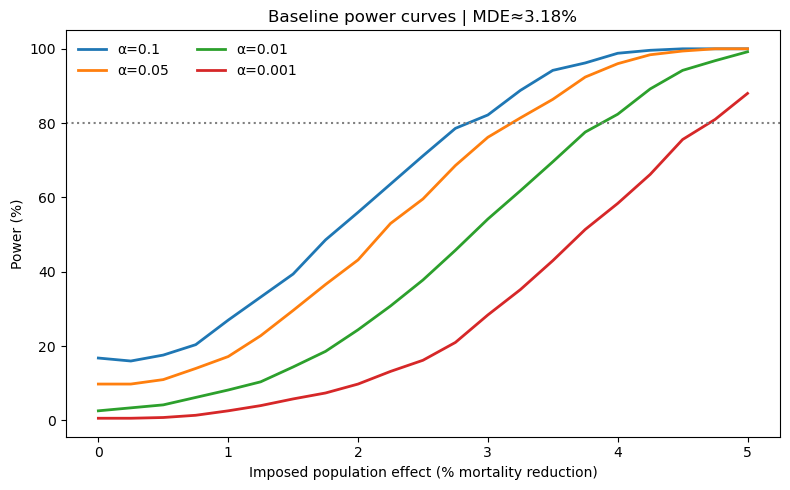


=== LLM proposing adjacent programs (same dataset) ===
Wrote adjacent_programs.json

=== Running program: baseline ===
Rationale: Baseline: log mortality rate per 100k + 1, state×year, pseudo post=2011


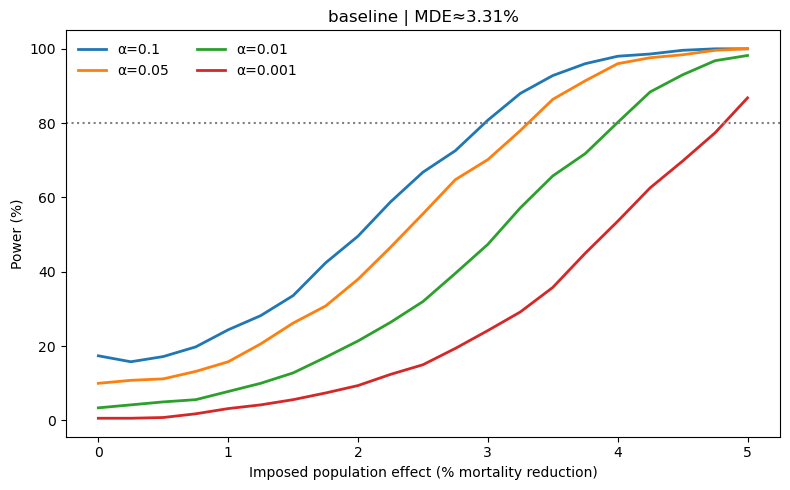


=== Running program: longer_pre_period ===
Rationale: Longer pre-period (12 years) to improve baseline trend estimation, same post period and treatment size


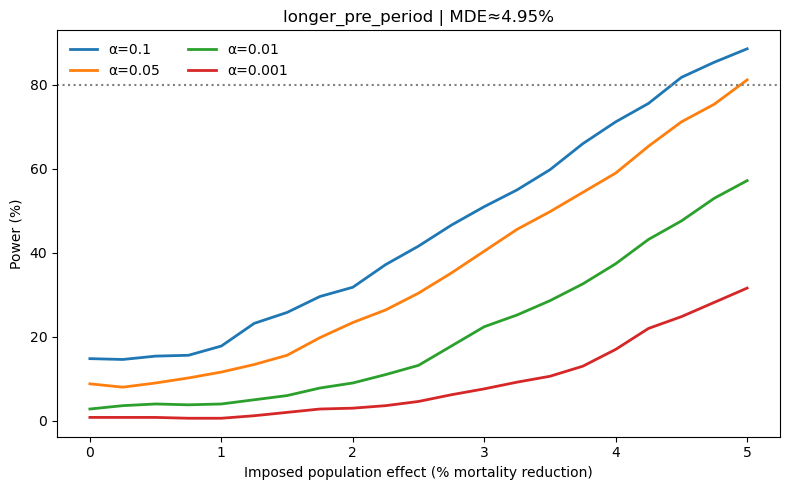


=== Running program: smaller_treated_group ===
Rationale: Smaller treated group (5 states) to reduce power, same baseline and post periods


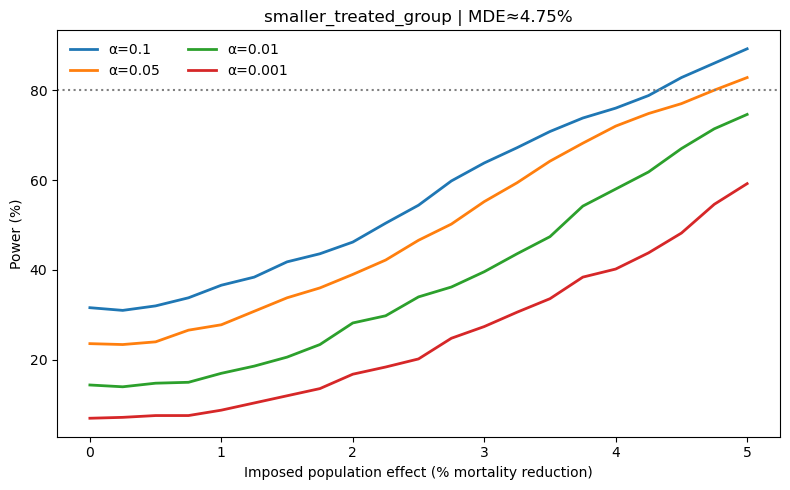


=== Running program: aggregate_data_asinh ===
Rationale: Aggregate deaths and population by state and year, use asinh transform to reduce influence of outliers, shorter post period and fewer simulations to reduce power


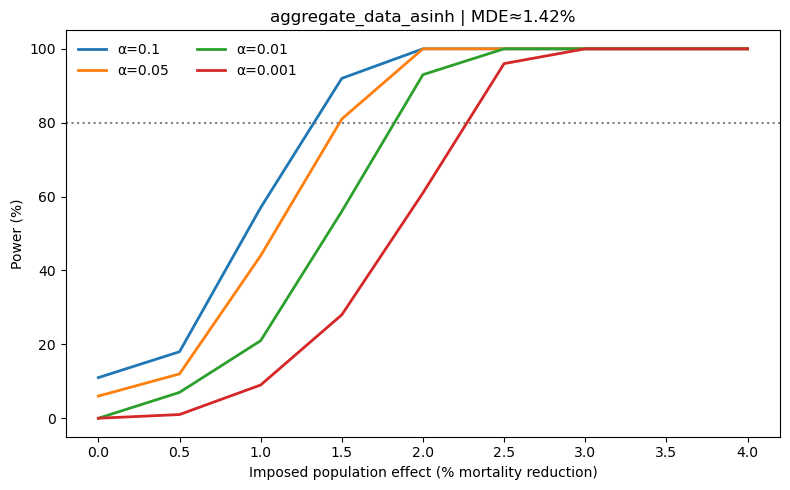


Wrote adjacent_program_results.csv
              program_id   mde_pct  last_year  pre_years  post_years  \
3   aggregate_data_asinh  1.421053       2012          3           1   
0               baseline  3.309524       2011          5           3   
2  smaller_treated_group  4.750000       2011          5           3   
1      longer_pre_period  4.948276       2011         12           3   

   n_treated  n_sim outcome_transform  
3         23    100        asinh_rate  
0         23    500          log_rate  
2          5    500          log_rate  
1         23    500          log_rate  


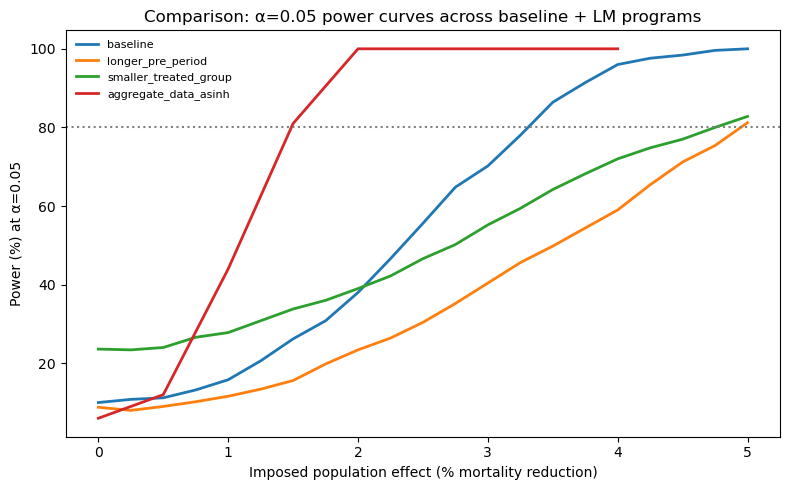

In [4]:
def plot_power_curves_multi_alpha(power_df: pd.DataFrame, title: str):
    plt.figure(figsize=(8,5))
    for a in ALPHAS:
        plt.plot(power_df["effect_size_pct"], power_df[f"power_{a:.3f}"], lw=2, label=f"α={a:g}")
    plt.axhline(80, color="gray", ls=":", lw=1.5)
    plt.xlabel("Imposed population effect (% mortality reduction)")
    plt.ylabel("Power (%)")
    plt.title(title)
    plt.legend(frameon=False, ncols=2)
    plt.tight_layout()
    plt.show()

def main():
    df_all = load_wonder_state_year(BASELINE_PATH)

    # baseline run
    print("\n=== Baseline program ===")
    df_base = apply_data_ops(df_all, BASELINE_PROGRAM["data_ops"])
    power_base = simulate_power_with_transform(df_base, BASELINE_PROGRAM["design_ops"],
                                               outcome_transform=BASELINE_PROGRAM["data_ops"]["outcome_transform"],
                                               seed=RNG_SEED)
    mde_base = mde_from_power_curve(power_base)
    print(f"Baseline MDE (α={ALPHA_FOR_MDE}, {TARGET_POWER}% power): {mde_base:.3f}%")
    plot_power_curves_multi_alpha(power_base, f"Baseline power curves | MDE≈{mde_base:.2f}%")

    # ask LM for programs
    print("\n=== LLM proposing adjacent programs (same dataset) ===")
    menu = propose_programs_via_llm(df_all, BASELINE_PROGRAM, k=4)
    with open("adjacent_programs.json", "w", encoding="utf-8") as f:
        f.write(menu.model_dump_json(indent=2))
    print("Wrote adjacent_programs.json")

    results = []
    power_by_id = {"baseline": power_base}

    for p in menu.programs:
        print(f"\n=== Running program: {p.program_id} ===")
        print("Rationale:", p.rationale)

        dfp = apply_data_ops(df_all, p.data_ops.model_dump())
        power_p = simulate_power_with_transform(dfp, p.design_ops.model_dump(),
                                                outcome_transform=p.data_ops.outcome_transform,
                                                seed=RNG_SEED + (hash(p.program_id) % 10000))
        mde_p = mde_from_power_curve(power_p)

        results.append({
            "program_id": p.program_id,
            "mde_pct": mde_p,
            **p.data_ops.model_dump(),
            **p.design_ops.model_dump(),
            "rationale": p.rationale,
        })
        power_by_id[p.program_id] = power_p

        plot_power_curves_multi_alpha(power_p, f"{p.program_id} | MDE≈{mde_p:.2f}%")

    res_df = pd.DataFrame(results).sort_values("mde_pct")
    res_df.to_csv("adjacent_program_results.csv", index=False)
    print("\nWrote adjacent_program_results.csv")
    print(res_df[["program_id","mde_pct","last_year","pre_years","post_years","n_treated","n_sim","outcome_transform"]])

    # comparison plot at alpha=0.05
    plt.figure(figsize=(8,5))
    for k, dfp in power_by_id.items():
        plt.plot(dfp["effect_size_pct"], dfp[f"power_{0.05:.3f}"], lw=2, label=k)
    plt.axhline(80, color="gray", ls=":")
    plt.xlabel("Imposed population effect (% mortality reduction)")
    plt.ylabel("Power (%) at α=0.05")
    plt.title("Comparison: α=0.05 power curves across baseline + LM programs")
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()